# Stage 2c: Shortcut Auditing — MentalRoBERTa (Frozen + Fine-tuned)

**Model:** `mental/mental-roberta-base` — RoBERTa-base pretrained on mental-health Reddit posts
(Ji et al., 2022, *MentalBERT: Publicly Available Pretrained Language Models for Mental Healthcare*).
This is the leading open-weight mental health PLM for classification.

**Comparison target:** Results from notebooks 02 (frozen distilroberta-base) and 02b (fine-tuned distilroberta-base).

**Key difference from distilroberta-base:** MentalRoBERTa has **12 transformer layers** (vs 6)
and was pretrained on in-domain mental health text, so its [CLS] may encode shortcut features
more strongly *even before* fine-tuning.

**Structure:**
- **Part A** — Frozen MentalRoBERTa: probing, layer-wise probing, SHAP, ablation
- **Part B** — Fine-tuned MentalRoBERTa: same analyses after task fine-tuning

All outputs → `data/stage2_mentalroberta/frozen/` and `data/stage2_mentalroberta/finetuned/`

In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, r2_score, f1_score
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset
import shap

sns.set_style('whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")

MODEL_NAME  = 'mental/mental-roberta-base'
MAX_LEN     = 256
BATCH_SIZE  = 64   # full RoBERTa-base is ~125M params vs ~82M for distilroberta

OUT_ROOT    = 'data/stage2_mentalroberta'
OUT_FROZEN  = f'{OUT_ROOT}/frozen'
OUT_FT      = f'{OUT_ROOT}/finetuned'
FT_MODEL_DIR = f'{OUT_ROOT}/ft_model'
for d in [OUT_FROZEN, OUT_FT, FT_MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Load Stage 1 metadata ────────────────────────────────────────────────────
with open('data/stage1/stage1_results.json') as f:
    stage1 = json.load(f)

SHORTCUT_FEATURES = stage1['shortcut_features']
CONTROL_FEATURES  = stage1['passed_controls']
ALL_18_FEATURES   = stage1['all_18_features']
SHORTCUT_META     = stage1['shortcut_meta']
PROBE_FEATURES    = SHORTCUT_FEATURES + CONTROL_FEATURES

print(f"Shortcuts ({len(SHORTCUT_FEATURES)}): {SHORTCUT_FEATURES}")
print(f"Controls  ({len(CONTROL_FEATURES)}): {CONTROL_FEATURES}")

Device: cuda  |  GPUs: 4
Shortcuts (8): ['fp_singular', 'analytic', 'body_health', 'post_length', 'self_ref_rumination', 'hedge_density', 'negative_emotion', 'emotional_feeling']
Controls  (2): ['cogproc', 'clout']


In [3]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_pickle('data/stage1/features_18_extracted.pkl')
df['text'] = df['text'].fillna('')

GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'
if 'binary_label' not in df.columns:
    df['binary_label'] = (~df['TID'].str.contains('control')).astype(int)

mf_mask = df[GENDER_COL].isin(['male', 'female'])
df_mf = df[mf_mask].copy()
df_mf['gender_bin'] = (df_mf[GENDER_COL] == 'female').astype(int)
mf_idx_arr = np.where(mf_mask.values)[0]

print(f"Loaded {len(df):,} rows | Label dist: {df['binary_label'].value_counts().to_dict()}")

# ── Shared targets for layer-wise probing ────────────────────────────────────
def build_targets(df, PROBE_FEATURES, SHORTCUT_FEATURES, GENDER_COL, mf_idx_arr):
    targets = {}
    for feat in PROBE_FEATURES:
        vals = df[feat].fillna(0).values.astype(float)
        targets[feat] = (vals > np.median(vals)).astype(int)
    targets['gender'] = (df.iloc[mf_idx_arr][GENDER_COL] == 'female').astype(int).values
    targets['binary_label'] = df['binary_label'].values.astype(int)
    return targets

targets = build_targets(df, PROBE_FEATURES, SHORTCUT_FEATURES, GENDER_COL, mf_idx_arr)

Loaded 32,200 rows | Label dist: {0: 22601, 1: 9599}


In [4]:
# ── Shared utilities ─────────────────────────────────────────────────────────

def extract_cls_embeddings(texts, model, tok, batch_size=BATCH_SIZE):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size) % 20 == 0:
            print(f"  Batch {i//batch_size+1}/{(len(texts)-1)//batch_size+1}", end='\r')
    print()
    return np.vstack(all_embs)


def extract_cls_all_layers(texts, model, tok, batch_size=BATCH_SIZE):
    n_layers = model.config.num_hidden_layers
    layer_embs = [[] for _ in range(n_layers + 1)]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        for li in range(n_layers + 1):
            layer_embs[li].append(out.hidden_states[li][:, 0, :].cpu().numpy())
        if (i // batch_size) % 25 == 0:
            print(f"  Batch {i//batch_size+1}/{(len(texts)-1)//batch_size+1}", end='\r')
    print()
    return [np.vstack(le) for le in layer_embs]


def gpu_probe_auc(X_np, y_np, n_splits=5, lr=0.01, epochs=200, batch_size=2048):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, te_idx in cv.split(X_np, y_np):
        X_tr = torch.tensor(X_np[tr_idx], dtype=torch.float32, device=DEVICE)
        y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32, device=DEVICE)
        X_te = torch.tensor(X_np[te_idx], dtype=torch.float32, device=DEVICE)
        y_te = y_np[te_idx]
        m = nn.Linear(X_tr.shape[1], 1).to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
        loss_fn = nn.BCEWithLogitsLoss()
        m.train()
        n = len(X_tr)
        for _ in range(epochs):
            perm = torch.randperm(n, device=DEVICE)
            for s in range(0, n, batch_size):
                idx = perm[s:s+batch_size]
                loss = loss_fn(m(X_tr[idx]).squeeze(-1), y_tr[idx])
                opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            probs = torch.sigmoid(m(X_te).squeeze(-1)).cpu().numpy()
        aucs.append(roc_auc_score(y_te, probs))
    return np.mean(aucs), np.std(aucs)


def run_probing(X_cls, df, PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
                GENDER_COL, mf_mask, df_mf):
    """Linear probing: regression R² + classification AUC for all features + gender + label."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cls)
    probe_results = []
    y_strat = df['binary_label'].values

    for feat in PROBE_FEATURES:
        y_cont = df[feat].fillna(0).values.astype(float)
        role = 'shortcut' if feat in SHORTCUT_FEATURES else 'control'
        # Regression
        ridge = Ridge(alpha=1.0)
        cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        r2s = []
        for tr, te in cv5.split(X_scaled, y_strat):
            ridge.fit(X_scaled[tr], y_cont[tr])
            r2s.append(r2_score(y_cont[te], ridge.predict(X_scaled[te])))
        # Classification
        y_bin = (y_cont > np.median(y_cont)).astype(int)
        clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
        aucs = cross_val_score(clf, X_scaled, y_bin,
                               cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                               scoring='roc_auc')
        probe_results.append({'feature': feat, 'role': role,
                               'probe_R2': np.mean(r2s),
                               'probe_AUC_median_split': aucs.mean(),
                               'probe_AUC_std': aucs.std()})
        print(f"  [{role:8s}] {feat:22s}  R²={np.mean(r2s):.4f}  AUC={aucs.mean():.3f}±{aucs.std():.3f}")

    # Gender
    mf_idx = df.index[mf_mask].tolist()
    X_mf = X_scaled[mf_idx]
    y_g = df_mf['gender_bin'].values
    aucs_g = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                              X_mf, y_g,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='roc_auc')
    print(f"  {'gender (m/f)':22s}  AUC={aucs_g.mean():.3f}±{aucs_g.std():.3f}")

    # Label
    y_l = df['binary_label'].values
    aucs_l = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                              X_scaled, y_l,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='roc_auc')
    print(f"  {'binary_label':22s}  AUC={aucs_l.mean():.3f}±{aucs_l.std():.3f}")

    return pd.DataFrame(probe_results), aucs_g, aucs_l, X_scaled


def run_layerwise_probing(all_layer_cls, targets, PROBE_FEATURES, SHORTCUT_FEATURES,
                          CONTROL_FEATURES, mf_idx_arr):
    n_layers = len(all_layer_cls)
    layer_names = ['Emb'] + [f'L{i}' for i in range(1, n_layers)]
    results = []
    for li in range(n_layers):
        X_sc = StandardScaler().fit_transform(all_layer_cls[li])
        for t_name, y in targets.items():
            X_probe = X_sc[mf_idx_arr] if t_name == 'gender' else X_sc
            auc_m, auc_s = gpu_probe_auc(X_probe, y)
            role = ('shortcut' if t_name in SHORTCUT_FEATURES
                    else 'control' if t_name in CONTROL_FEATURES
                    else 'meta')
            results.append({'layer': li, 'layer_name': layer_names[li],
                             'target': t_name, 'role': role,
                             'AUC': auc_m, 'AUC_std': auc_s})
        print(f"  Layer {layer_names[li]:4s} done")
    return pd.DataFrame(results), layer_names


def run_ablation(df, ALL_18_FEATURES, SHORTCUT_FEATURES, GENDER_COL):
    X_all = df[ALL_18_FEATURES].fillna(0).values.astype(float)
    y_all = df['binary_label'].values.astype(int)
    sc18 = StandardScaler()
    X_s = sc18.fit_transform(X_all)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    base_aucs = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                 X_s, y_all, cv=cv, scoring='roc_auc')
    baseline_auc = base_aucs.mean()
    print(f"Baseline (18 features): AUC = {baseline_auc:.4f} ± {base_aucs.std():.4f}")

    abl_results = []
    for feat in SHORTCUT_FEATURES:
        fi = ALL_18_FEATURES.index(feat)
        X_a = X_s.copy(); X_a[:, fi] = 0
        aucs_a = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                  X_a, y_all, cv=cv, scoring='roc_auc')
        drop = baseline_auc - aucs_a.mean()
        abl_results.append({'ablated': feat, 'AUC_after': aucs_a.mean(),
                             'AUC_std': aucs_a.std(), 'AUC_drop': drop,
                             'drop_pct': drop / baseline_auc * 100})
        print(f"  Ablate {feat:25s}: AUC={aucs_a.mean():.4f}  (Δ={drop:+.4f})")

    fi_all = [ALL_18_FEATURES.index(f) for f in SHORTCUT_FEATURES]
    X_a_all = X_s.copy(); X_a_all[:, fi_all] = 0
    aucs_all = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                X_a_all, y_all, cv=cv, scoring='roc_auc')
    drop_all = baseline_auc - aucs_all.mean()
    print(f"  Ablate ALL: AUC={aucs_all.mean():.4f}  (Δ={drop_all:+.4f})")

    # Gender-stratified
    clf_full = LogisticRegression(max_iter=1000, random_state=42)
    clf_full.fit(X_s, y_all)
    genders = df[GENDER_COL].values
    strat_results = []
    for gender in ['male', 'female']:
        g_mask = genders == gender
        X_g = X_s[g_mask]; y_g = y_all[g_mask]
        if len(np.unique(y_g)) < 2: continue
        base_g = roc_auc_score(y_g, clf_full.predict_proba(X_g)[:, 1])
        for feat in SHORTCUT_FEATURES:
            fi = ALL_18_FEATURES.index(feat)
            X_ga = X_g.copy(); X_ga[:, fi] = 0
            abl_g = roc_auc_score(y_g, clf_full.predict_proba(X_ga)[:, 1])
            d = base_g - abl_g
            strat_results.append({'gender': gender, 'ablated': feat,
                                   'baseline_AUC': base_g, 'ablated_AUC': abl_g,
                                   'AUC_drop': d, 'drop_pct': d / base_g * 100})

    return pd.DataFrame(abl_results), pd.DataFrame(strat_results), baseline_auc, aucs_all, drop_all


def plot_probing(probe_df, aucs_g, aucs_l, PROBE_FEATURES, SHORTCUT_FEATURES,
                 CONTROL_FEATURES, title_suffix, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    probe_labels = PROBE_FEATURES + ['gender (m/f)', 'binary_label']
    probe_aucs = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
                  for f in PROBE_FEATURES] + [aucs_g.mean(), aucs_l.mean()]
    probe_stds = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_std'].values[0]
                  for f in PROBE_FEATURES] + [aucs_g.std(), aucs_l.std()]
    colors = (['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
              + ['#3498db', '#2c3e50'])
    axes[0].barh(range(len(probe_labels)), probe_aucs, xerr=probe_stds,
                 color=colors, edgecolor='white')
    axes[0].set_yticks(range(len(probe_labels)))
    axes[0].set_yticklabels(probe_labels, fontsize=10)
    axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5)
    axes[0].set_xlabel('Probe AUC (5-fold CV)')
    axes[0].set_title(f'[CLS] Linear Probe\n{title_suffix}\n(red=shortcut, green=control)')
    for i, (a, s) in enumerate(zip(probe_aucs, probe_stds)):
        axes[0].text(a+s+0.005, i, f'{a:.3f}', va='center', fontsize=9)

    r2_vals = probe_df['probe_R2'].values
    r2_colors = ['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
    axes[1].barh(range(len(PROBE_FEATURES)), r2_vals, color=r2_colors, edgecolor='white')
    axes[1].set_yticks(range(len(PROBE_FEATURES)))
    axes[1].set_yticklabels(PROBE_FEATURES, fontsize=10)
    axes[1].set_xlabel('Regression Probe R²')
    axes[1].set_title(f'[CLS] → Feature Value Recovery\n{title_suffix}')
    for i, r2 in enumerate(r2_vals):
        axes[1].text(max(r2,0)+0.002, i, f'{r2:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved → {save_path}")


def plot_layerwise(layer_probe_df, layer_names, SHORTCUT_FEATURES, CONTROL_FEATURES,
                   all_targets_ordered, title_suffix, save_prefix):
    n_layers = len(layer_names)
    layers_x = np.arange(n_layers)
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    cmap_sc = plt.cm.Set1(np.linspace(0, 0.7, len(SHORTCUT_FEATURES)))
    row_g = layer_probe_df[layer_probe_df['target']=='gender'].sort_values('layer')
    row_l = layer_probe_df[layer_probe_df['target']=='binary_label'].sort_values('layer')

    for i, feat in enumerate(SHORTCUT_FEATURES):
        row = layer_probe_df[layer_probe_df['target']==feat].sort_values('layer')
        axes[0].plot(layers_x, row['AUC'].values, 'o-', color=cmap_sc[i],
                     label=feat, linewidth=2, markersize=5)
    axes[0].plot(layers_x, row_g['AUC'].values, 's--', color='black', label='gender', linewidth=2.5)
    axes[0].plot(layers_x, row_l['AUC'].values, 'D--', color='grey', label='binary_label', linewidth=2.5)
    axes[0].axhline(0.5, color='lightgrey', linestyle=':')
    axes[0].set_xticks(layers_x); axes[0].set_xticklabels(layer_names, fontsize=8, rotation=45)
    axes[0].set_ylabel('Probe AUC'); axes[0].set_ylim(0.48, 1.02)
    axes[0].set_title(f'Shortcuts Across Depth\n{title_suffix}', fontweight='bold')
    axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

    cmap_ctrl = plt.cm.Dark2(np.linspace(0, 0.6, len(CONTROL_FEATURES)))
    for i, feat in enumerate(CONTROL_FEATURES):
        row = layer_probe_df[layer_probe_df['target']==feat].sort_values('layer')
        axes[1].plot(layers_x, row['AUC'].values, 'o-', color=cmap_ctrl[i],
                     label=feat, linewidth=2, markersize=5)
    axes[1].plot(layers_x, row_g['AUC'].values, 's--', color='black', label='gender', linewidth=2.5)
    axes[1].plot(layers_x, row_l['AUC'].values, 'D--', color='grey', label='binary_label', linewidth=2.5)
    axes[1].axhline(0.5, color='lightgrey', linestyle=':')
    axes[1].set_xticks(layers_x); axes[1].set_xticklabels(layer_names, fontsize=8, rotation=45)
    axes[1].set_ylabel('Probe AUC'); axes[1].set_ylim(0.48, 1.02)
    axes[1].set_title(f'Controls Across Depth\n{title_suffix}', fontweight='bold')
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

    deltas, auc_e, auc_f = [], [], []
    for t in all_targets_ordered:
        row = layer_probe_df[layer_probe_df['target']==t].sort_values('layer')
        auc_e.append(row['AUC'].values[0]); auc_f.append(row['AUC'].values[-1])
        deltas.append(row['AUC'].values[-1] - row['AUC'].values[0])
    bar_colors = (['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
                  + ['#3498db', '#2c3e50'])
    axes[2].barh(range(len(all_targets_ordered)), deltas, color=bar_colors, edgecolor='white')
    axes[2].set_yticks(range(len(all_targets_ordered)))
    axes[2].set_yticklabels(all_targets_ordered, fontsize=9)
    axes[2].axvline(0, color='grey', linewidth=0.5)
    axes[2].set_xlabel('ΔAUC (Final − Emb)')
    axes[2].set_title(f'Depth Gain\n{title_suffix}', fontweight='bold')
    for i, (d, ae, af) in enumerate(zip(deltas, auc_e, auc_f)):
        axes[2].text(max(d,0)+0.002, i, f'{ae:.3f}→{af:.3f} (Δ{d:+.3f})', va='center', fontsize=8)
    axes[2].grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_layerwise.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Heatmap
    hm_data = layer_probe_df.pivot(index='target', columns='layer_name', values='AUC')
    hm_data = hm_data.loc[all_targets_ordered, layer_names]
    row_labels = ([f'★ {f}' for f in SHORTCUT_FEATURES] + [f'◇ {f}' for f in CONTROL_FEATURES]
                  + ['■ gender', '■ binary_label'])
    fig, ax = plt.subplots(figsize=(max(10, n_layers), 8))
    im = ax.imshow(hm_data.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(n_layers)); ax.set_xticklabels(layer_names, fontsize=9, rotation=45)
    ax.set_yticks(range(len(all_targets_ordered)))
    ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_title(f'Layer-wise Probing AUC Heatmap\n{title_suffix}', fontsize=12, fontweight='bold')
    for i in range(len(all_targets_ordered)):
        for j in range(n_layers):
            val = hm_data.values[i, j]
            c = 'white' if val > 0.85 or val < 0.55 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7, color=c, fontweight='bold')
    ax.axhline(len(SHORTCUT_FEATURES)-0.5, color='black', linewidth=1.5)
    ax.axhline(len(SHORTCUT_FEATURES)+len(CONTROL_FEATURES)-0.5, color='black', linewidth=1.5)
    plt.colorbar(im, ax=ax, label='Probe AUC', shrink=0.8)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_prefix}_layerwise.png + _heatmap.png")


def plot_ablation(ablation_df, strat_df, baseline_auc, drop_all,
                  SHORTCUT_FEATURES, title_suffix, save_path):
    n_short = len(SHORTCUT_FEATURES)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    abl_labels = list(ablation_df['ablated']) + [f'All {n_short} shortcuts']
    abl_drops  = list(ablation_df['AUC_drop']) + [drop_all]
    cmap = plt.cm.Set2(np.linspace(0, 1, n_short+1))
    axes[0].barh(range(len(abl_labels)), abl_drops,
                 color=[cmap[i] for i in range(len(abl_labels))], edgecolor='white')
    axes[0].set_yticks(range(len(abl_labels))); axes[0].set_yticklabels(abl_labels, fontsize=9)
    axes[0].set_xlabel('AUC Drop After Ablation')
    axes[0].set_title(f'Feature Ablation (baseline={baseline_auc:.4f})\n{title_suffix}')
    axes[0].axvline(0, color='grey', linewidth=0.5)
    for i, d in enumerate(abl_drops):
        axes[0].text(max(d,0)+0.0003, i, f'{d:+.4f}', va='center', fontsize=9)

    x = np.arange(n_short); w = 0.35
    m_drops = strat_df[strat_df['gender']=='male'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
    f_drops = strat_df[strat_df['gender']=='female'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
    axes[1].bar(x-w/2, m_drops, w, label='Male',   color='#3498db', alpha=0.85)
    axes[1].bar(x+w/2, f_drops, w, label='Female', color='#e74c3c', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
    axes[1].set_ylabel('AUC Drop')
    axes[1].set_title(f'Gender-Stratified Ablation\n{title_suffix}')
    axes[1].legend(); axes[1].axhline(0, color='grey', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved → {save_path}")


print("Utility functions defined.")

Utility functions defined.


---
# Part A — Frozen MentalRoBERTa

Pretrained `mental/mental-roberta-base` with no task fine-tuning.
The model was pretrained on mental health Reddit posts, so it may encode shortcut features
more strongly than generic distilroberta-base even in frozen form.

In [5]:
print(f"Loading frozen {MODEL_NAME} …")
tokenizer_frozen = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder_frozen   = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

n_params = sum(p.numel() for p in encoder_frozen.parameters()) / 1e6
n_layers = encoder_frozen.config.num_hidden_layers
print(f"  Parameters: {n_params:.1f}M  |  Transformer layers: {n_layers}")

Loading frozen mental/mental-roberta-base …


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 28388.58it/s]
RobertaModel LOAD REPORT from: mental/mental-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Parameters: 124.6M  |  Transformer layers: 12


In [6]:
print(f"Extracting [CLS] embeddings (frozen) for {len(df):,} posts …")
X_cls_frozen = extract_cls_embeddings(df['text'].tolist(), encoder_frozen, tokenizer_frozen)
print(f"Shape: {X_cls_frozen.shape}")
np.save(f'{OUT_FROZEN}/cls_embeddings.npy', X_cls_frozen)
print(f"Saved → {OUT_FROZEN}/cls_embeddings.npy")

Extracting [CLS] embeddings (frozen) for 32,200 posts …


KeyboardInterrupt: 

## A1 — Probing Classifiers (Frozen)

In [ ]:
print("Running probing on frozen MentalRoBERTa [CLS] …")
probe_df_frozen, aucs_g_frozen, aucs_l_frozen, X_cls_frozen_sc = run_probing(
    X_cls_frozen, df, PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
    GENDER_COL, mf_mask, df_mf
)
probe_df_frozen

Running probing on frozen MentalRoBERTa [CLS] …
  [shortcut] fp_singular             R²=0.8267  AUC=0.968±0.002
  [shortcut] analytic                R²=0.7248  AUC=0.933±0.004
  [shortcut] body_health             R²=0.6642  AUC=0.877±0.002
  [shortcut] post_length             R²=0.3981  AUC=0.995±0.000
  [shortcut] self_ref_rumination     R²=0.3573  AUC=0.901±0.003
  [shortcut] hedge_density           R²=0.4014  AUC=0.829±0.004
  [shortcut] negative_emotion        R²=0.3296  AUC=0.888±0.005
  [shortcut] emotional_feeling       R²=0.4892  AUC=0.852±0.005
  [control ] cogproc                 R²=0.6441  AUC=0.883±0.004
  [control ] clout                   R²=0.6817  AUC=0.932±0.003
  gender (m/f)            AUC=0.948±0.004
  binary_label            AUC=0.806±0.005


,feature,role,probe_R2,probe_AUC_median_split,probe_AUC_std
0,fp_singular,shortcut,0.826725,0.968291,0.001520
1,analytic,shortcut,0.724772,0.933480,0.003634
2,body_health,shortcut,0.664232,0.877240,0.002201
3,post_length,shortcut,0.398088,0.995101,0.000472
4,self_ref_rumination,shortcut,0.357346,0.901237,0.002971
5,hedge_density,shortcut,0.401405,0.829265,0.003623
6,negative_emotion,shortcut,0.329565,0.888302,0.005251
7,emotional_feeling,shortcut,0.489211,0.851670,0.004900
8,cogproc,control,0.644063,0.883395,0.004071
9,clout,control,0.681708,0.932473,0.002937


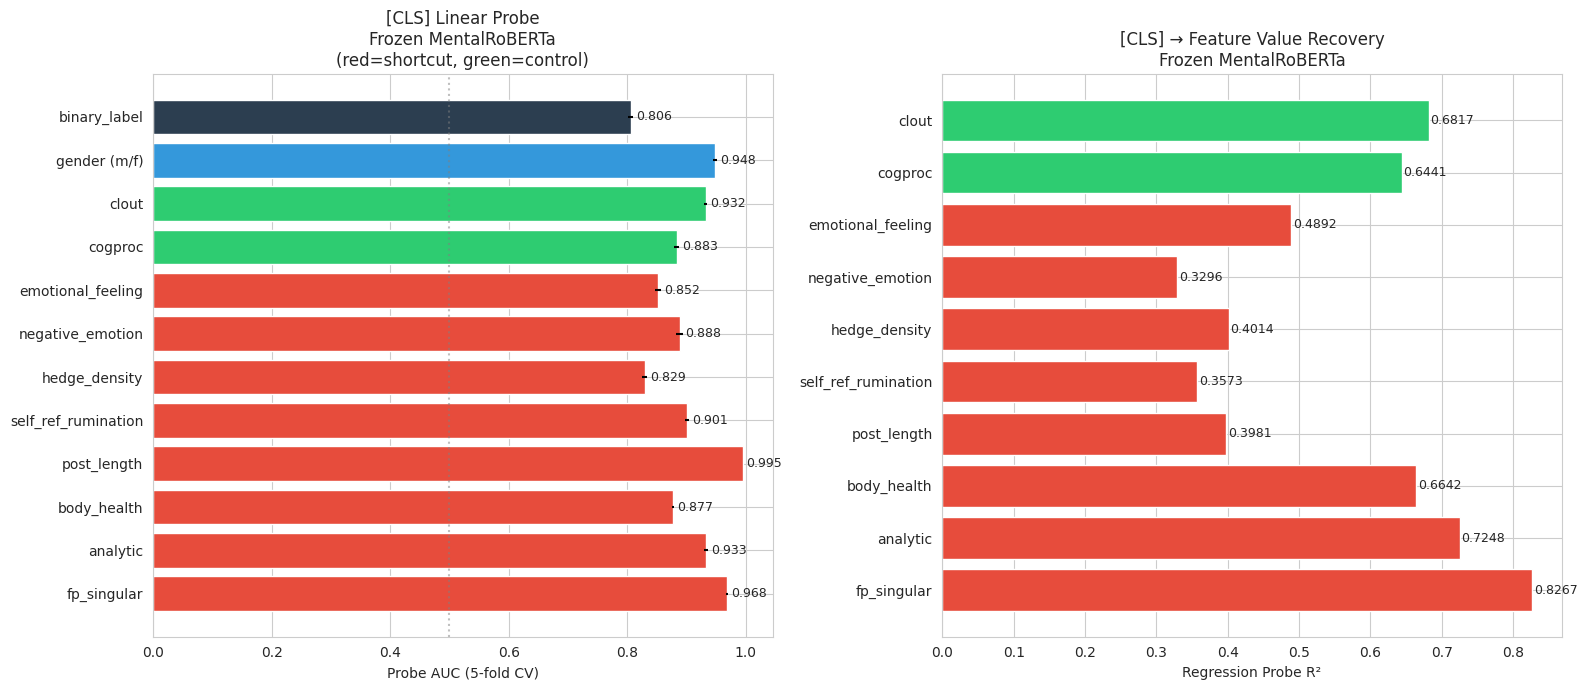

Saved → data/stage2_mentalroberta/frozen/probing_results.png


In [ ]:
plot_probing(probe_df_frozen, aucs_g_frozen, aucs_l_frozen,
             PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
             title_suffix='Frozen MentalRoBERTa',
             save_path=f'{OUT_FROZEN}/probing_results.png')
probe_df_frozen.to_csv(f'{OUT_FROZEN}/probing_results.csv', index=False)

## A2 — Layer-wise Probing (Frozen)

In [7]:
print(f"Extracting all-layer [CLS] (frozen) for {len(df):,} posts …")
all_layer_cls_frozen = extract_cls_all_layers(df['text'].tolist(), encoder_frozen, tokenizer_frozen)
print(f"Got {len(all_layer_cls_frozen)} layers, shape {all_layer_cls_frozen[0].shape}")

Extracting all-layer [CLS] (frozen) for 32,200 posts …
  Batch 501/504
Got 13 layers, shape (32200, 768)


In [8]:
print("Running layer-wise probing (frozen) …")
layer_probe_df_frozen, layer_names_frozen = run_layerwise_probing(
    all_layer_cls_frozen, targets, PROBE_FEATURES,
    SHORTCUT_FEATURES, CONTROL_FEATURES, mf_idx_arr
)

pivot_frozen = layer_probe_df_frozen.pivot(index='target', columns='layer_name', values='AUC')
pivot_frozen = pivot_frozen[layer_names_frozen]
print(pivot_frozen.round(3).to_string())

Running layer-wise probing (frozen) …
  Layer Emb  done
  Layer L1   done
  Layer L2   done
  Layer L3   done
  Layer L4   done
  Layer L5   done
  Layer L6   done
  Layer L7   done
  Layer L8   done
  Layer L9   done
  Layer L10  done
  Layer L11  done
  Layer L12  done
layer_name           Emb     L1     L2     L3     L4     L5     L6     L7     L8     L9    L10    L11    L12
target                                                                                                      
analytic             0.5  0.969  0.967  0.961  0.956  0.947  0.944  0.936  0.921  0.901  0.883  0.905  0.931
binary_label         0.5  0.780  0.782  0.781  0.789  0.790  0.793  0.793  0.788  0.785  0.766  0.789  0.800
body_health          0.5  0.881  0.878  0.880  0.878  0.878  0.870  0.870  0.855  0.825  0.819  0.854  0.874
clout                0.5  0.941  0.943  0.935  0.932  0.930  0.927  0.919  0.900  0.884  0.873  0.909  0.930
cogproc              0.5  0.915  0.916  0.910  0.907  0.896  0.896  0.893 

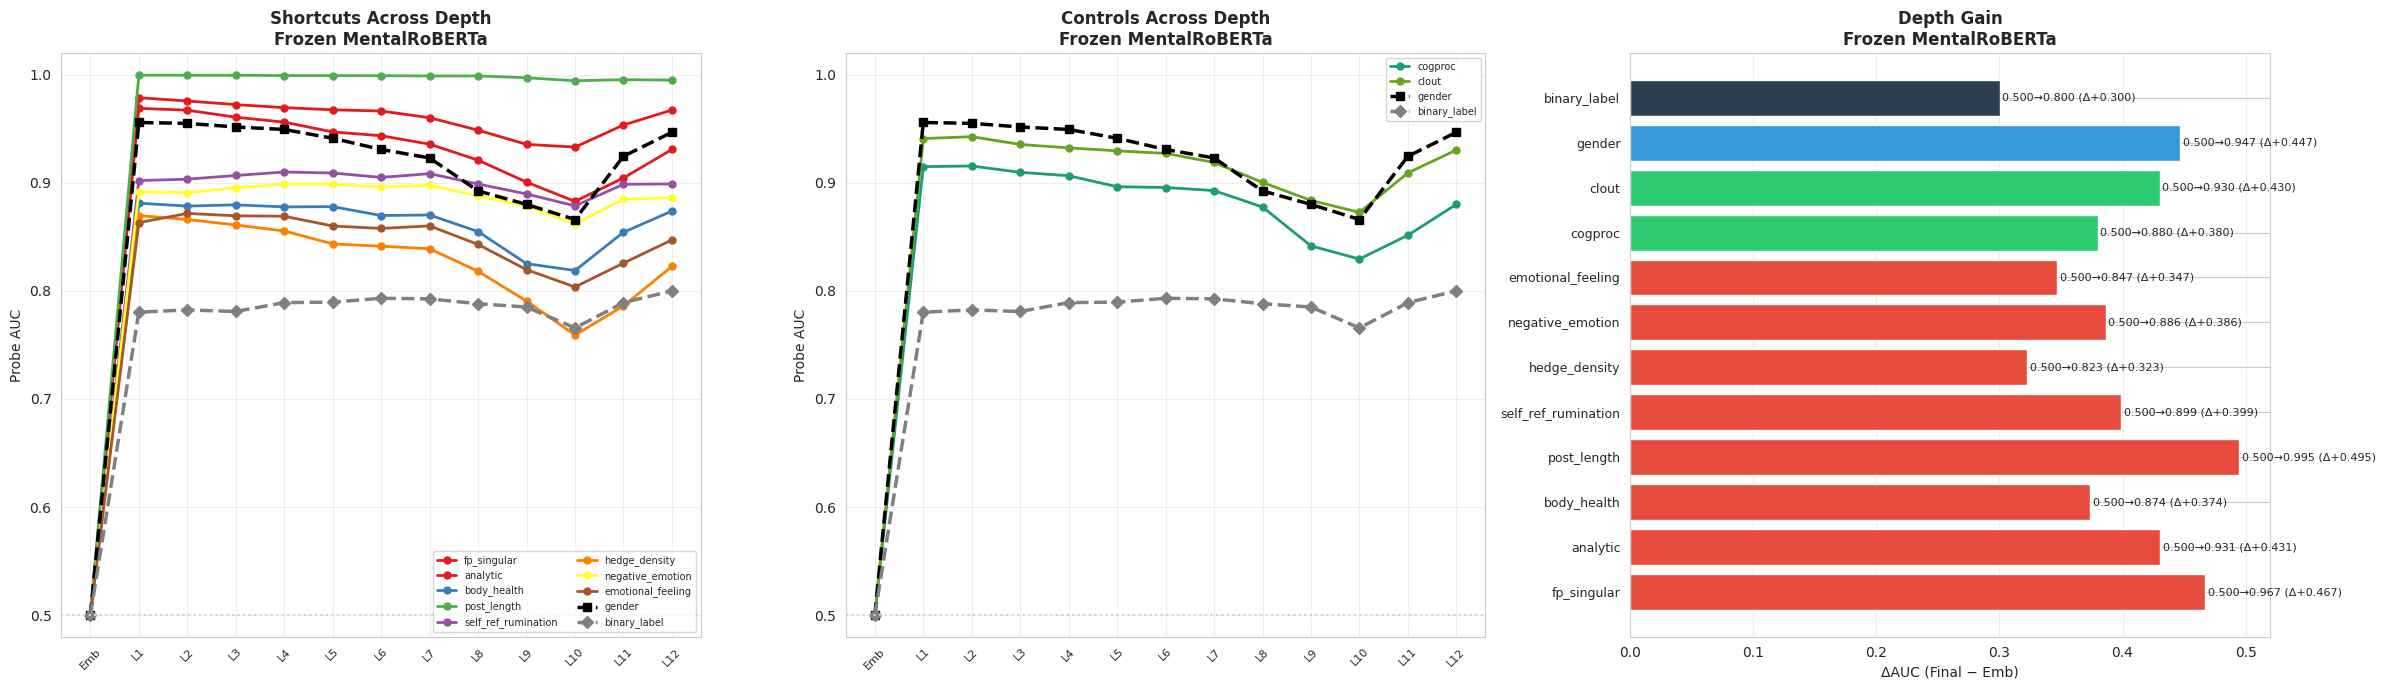

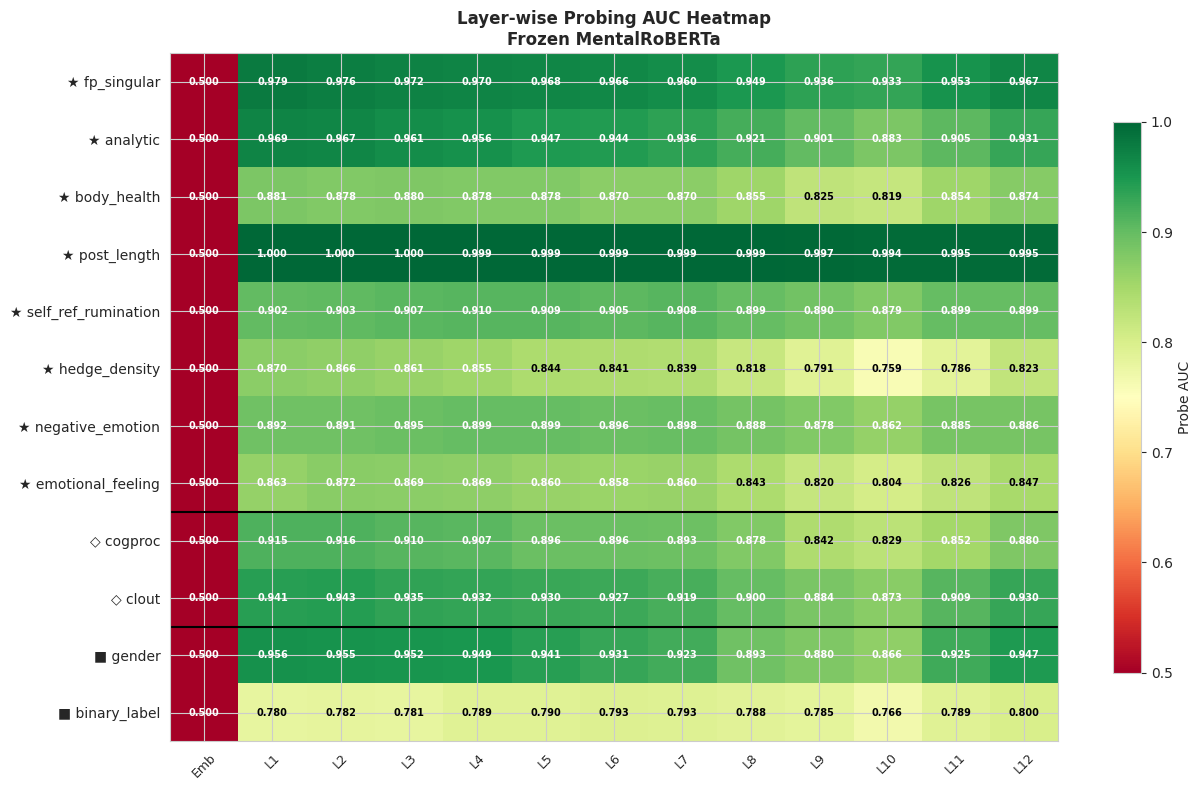

Saved → data/stage2_mentalroberta/frozen/layerwise_layerwise.png + _heatmap.png


In [9]:
all_targets_ordered = SHORTCUT_FEATURES + CONTROL_FEATURES + ['gender', 'binary_label']
plot_layerwise(layer_probe_df_frozen, layer_names_frozen,
               SHORTCUT_FEATURES, CONTROL_FEATURES, all_targets_ordered,
               title_suffix='Frozen MentalRoBERTa',
               save_prefix=f'{OUT_FROZEN}/layerwise')
layer_probe_df_frozen.to_csv(f'{OUT_FROZEN}/layerwise_probing.csv', index=False)

## A3 — SHAP Attribution (Frozen)

In [10]:
X_short = df[SHORTCUT_FEATURES].fillna(0).values.astype(float)
y_label = df['binary_label'].values.astype(int)
sc_sh = StandardScaler()
X_short_sc = sc_sh.fit_transform(X_short)

clf_shap = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_shap.fit(X_short_sc, y_label)
auc_short = roc_auc_score(y_label, clf_shap.predict_proba(X_short_sc)[:, 1])
print(f"8-shortcut logistic AUC (train): {auc_short:.4f}")

explainer = shap.LinearExplainer(clf_shap, X_short_sc, feature_names=SHORTCUT_FEATURES)
shap_values = explainer.shap_values(X_short_sc)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
print("Mean |SHAP|:")
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    print(f"  {feat:25s}: {val:.4f}  ({val/mean_abs_shap.sum()*100:.1f}%)")

8-shortcut logistic AUC (train): 0.7123
Mean |SHAP|:
  analytic                 : 0.3204  (31.7%)
  fp_singular              : 0.2317  (22.9%)
  body_health              : 0.1899  (18.8%)
  negative_emotion         : 0.1127  (11.2%)
  post_length              : 0.0944  (9.3%)
  emotional_feeling        : 0.0347  (3.4%)
  hedge_density            : 0.0180  (1.8%)
  self_ref_rumination      : 0.0090  (0.9%)


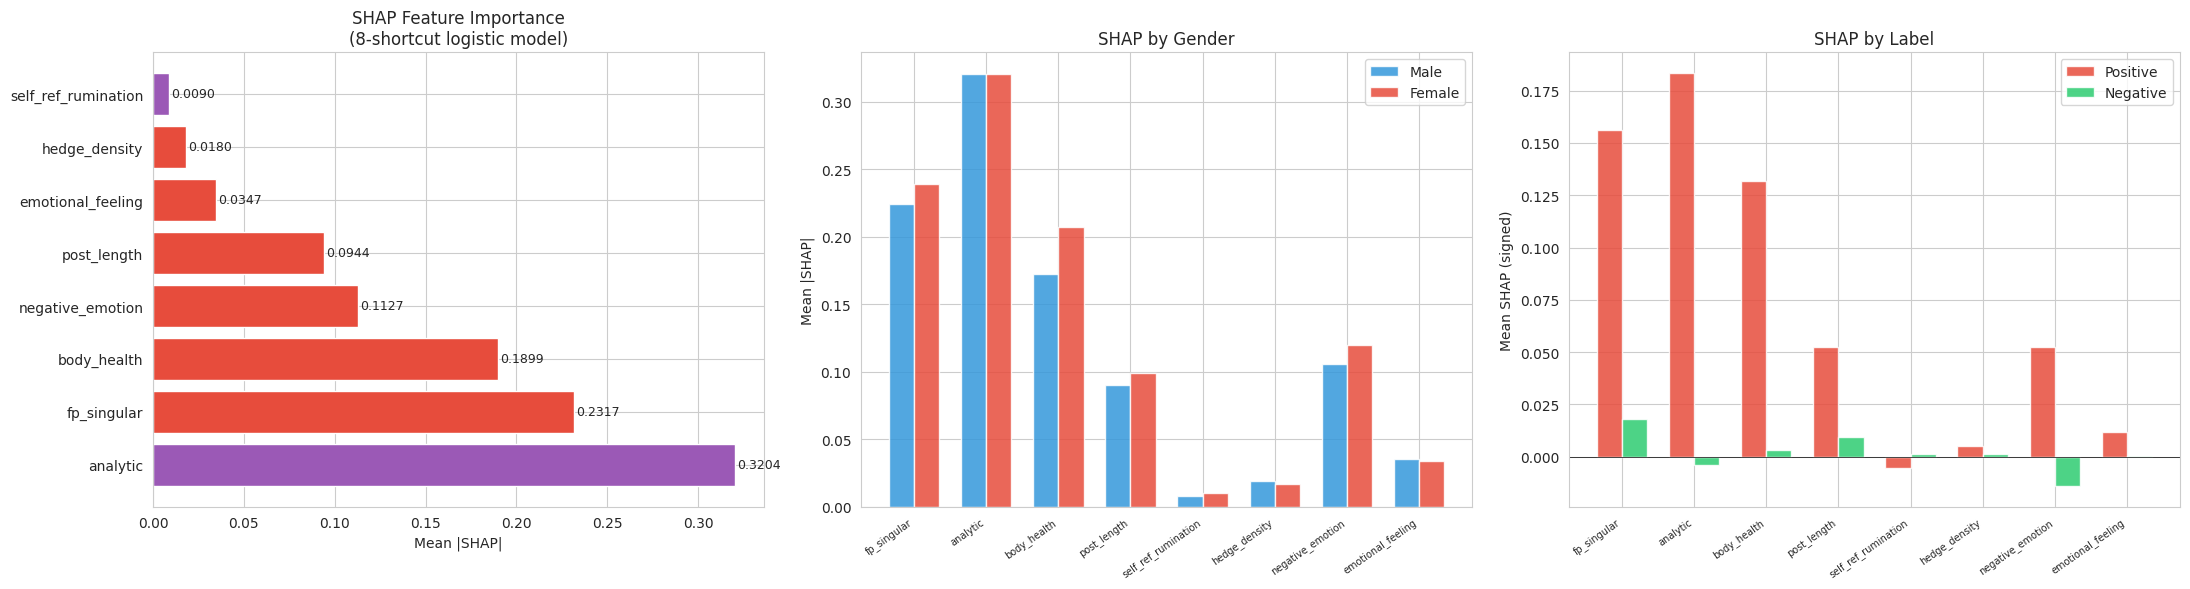

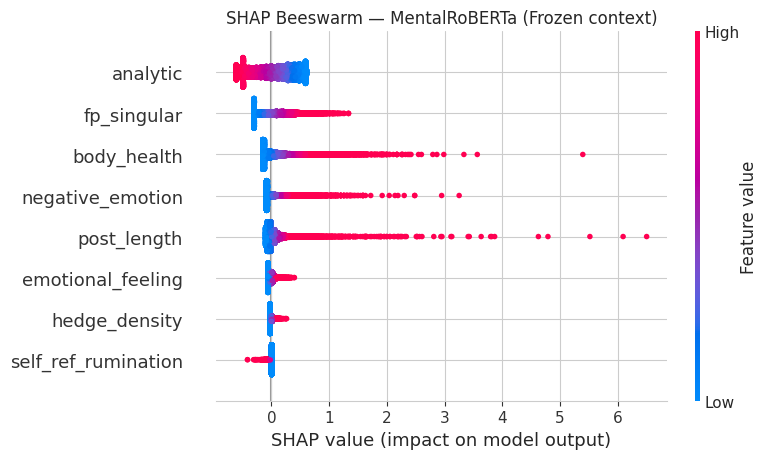

Saved → data/stage2_mentalroberta/frozen/shap_*.png


In [11]:
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
bar_c = ['#9b59b6' if SHORTCUT_META[SHORTCUT_FEATURES[i]].get('was_control', False)
          else '#e74c3c' for i in order]
axes[0].barh(range(len(order)), mean_abs[order], color=bar_c, edgecolor='white')
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([SHORTCUT_FEATURES[i] for i in order], fontsize=10)
axes[0].set_xlabel('Mean |SHAP|')
axes[0].set_title('SHAP Feature Importance\n(8-shortcut logistic model)')
for i, idx in enumerate(order):
    axes[0].text(mean_abs[idx]+0.001, i, f'{mean_abs[idx]:.4f}', va='center', fontsize=9)

shap_df = pd.DataFrame(shap_values, columns=SHORTCUT_FEATURES)
shap_df['gender'] = df[GENDER_COL].values
x = np.arange(n_short); w = 0.35
axes[1].bar(x-w/2, shap_df[shap_df['gender']=='male'][SHORTCUT_FEATURES].abs().mean().values,
            w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x+w/2, shap_df[shap_df['gender']=='female'][SHORTCUT_FEATURES].abs().mean().values,
            w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[1].set_ylabel('Mean |SHAP|'); axes[1].set_title('SHAP by Gender'); axes[1].legend()

pos_s = shap_df[df['binary_label'].values==1][SHORTCUT_FEATURES].mean()
neg_s = shap_df[df['binary_label'].values==0][SHORTCUT_FEATURES].mean()
axes[2].bar(x-w/2, pos_s.values, w, label='Positive', color='#e74c3c', alpha=0.85)
axes[2].bar(x+w/2, neg_s.values, w, label='Negative', color='#2ecc71', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[2].set_ylabel('Mean SHAP (signed)'); axes[2].set_title('SHAP by Label')
axes[2].axhline(0, color='black', linewidth=0.5); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUT_FROZEN}/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

shap_expl = shap.Explanation(values=shap_values,
                              base_values=np.full(len(shap_values), explainer.expected_value),
                              data=X_short_sc, feature_names=SHORTCUT_FEATURES)
fig, ax = plt.subplots(figsize=(12, 6))
shap.plots.beeswarm(shap_expl, show=False, max_display=n_short)
plt.title('SHAP Beeswarm — MentalRoBERTa (Frozen context)')
plt.tight_layout()
plt.savefig(f'{OUT_FROZEN}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
np.save(f'{OUT_FROZEN}/shap_values.npy', shap_values)
print(f"Saved → {OUT_FROZEN}/shap_*.png")

## A4 — Feature Ablation (Frozen)

In [12]:
ablation_df_frozen, strat_df_frozen, baseline_auc_frozen, aucs_all_frozen, drop_all_frozen = \
    run_ablation(df, ALL_18_FEATURES, SHORTCUT_FEATURES, GENDER_COL)
ablation_df_frozen

Baseline (18 features): AUC = 0.7214 ± 0.0074
  Ablate fp_singular              : AUC=0.7166  (Δ=+0.0049)
  Ablate analytic                 : AUC=0.7186  (Δ=+0.0028)
  Ablate body_health              : AUC=0.7032  (Δ=+0.0182)
  Ablate post_length              : AUC=0.7173  (Δ=+0.0041)
  Ablate self_ref_rumination      : AUC=0.7215  (Δ=-0.0000)
  Ablate hedge_density            : AUC=0.7215  (Δ=-0.0001)
  Ablate negative_emotion         : AUC=0.7208  (Δ=+0.0006)
  Ablate emotional_feeling        : AUC=0.7214  (Δ=-0.0000)
  Ablate ALL: AUC=0.6503  (Δ=+0.0711)


,ablated,AUC_after,AUC_std,AUC_drop,drop_pct
0,fp_singular,0.716560,0.008243,0.004857,0.673260
1,analytic,0.718633,0.007361,0.002784,0.385926
2,body_health,0.703240,0.005938,0.018176,2.519555
3,post_length,0.717294,0.007624,0.004123,0.571505
4,self_ref_rumination,0.721459,0.007360,-0.000042,-0.005855
5,hedge_density,0.721535,0.007457,-0.000119,-0.016458
6,negative_emotion,0.720826,0.007283,0.000590,0.081829
7,emotional_feeling,0.721434,0.007421,-0.000017,-0.002387


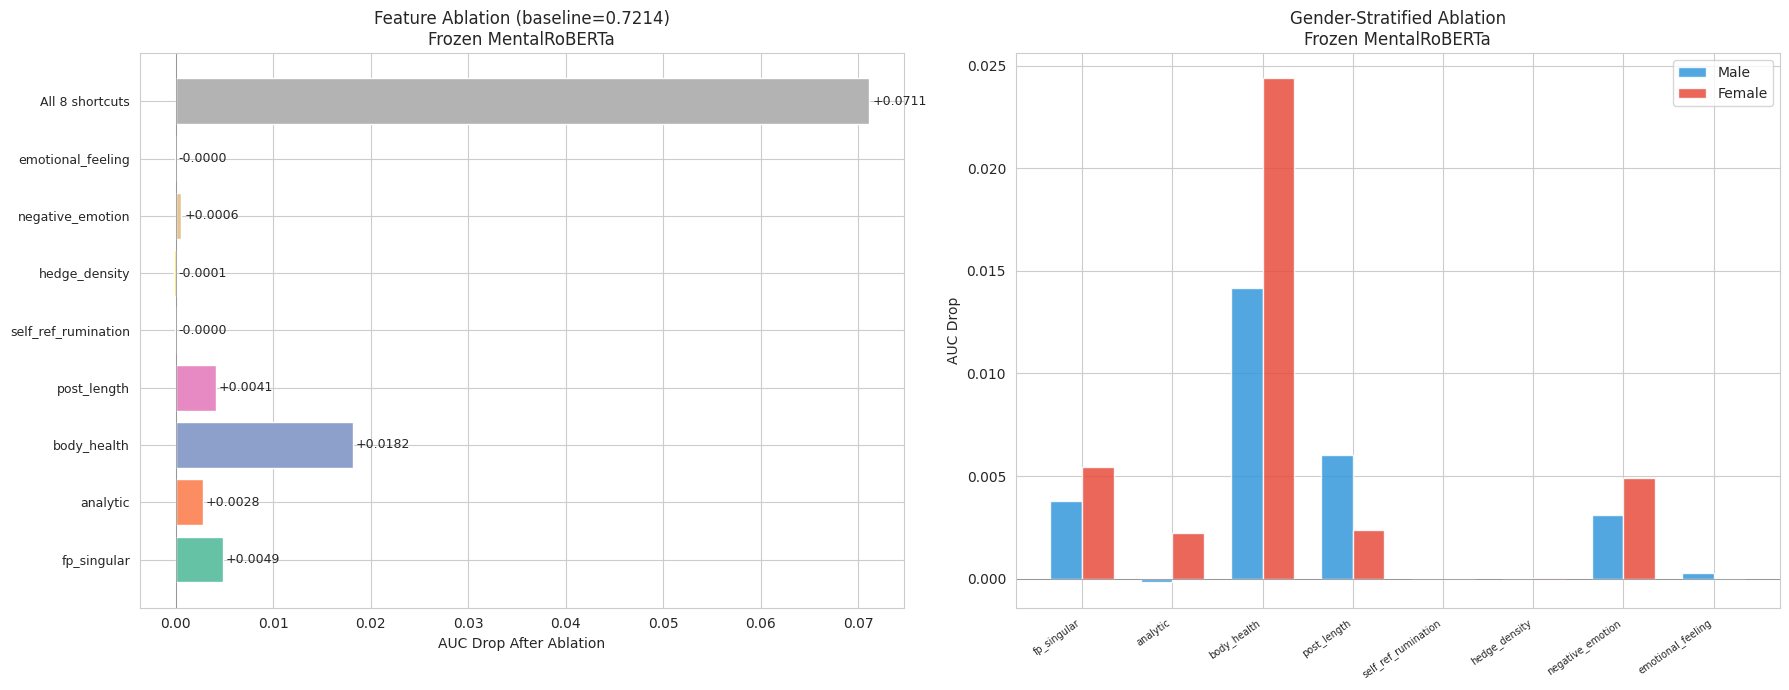

Saved → data/stage2_mentalroberta/frozen/ablation_analysis.png

=== PART A SUMMARY (Frozen MentalRoBERTa) ===


NameError: name 'probe_df_frozen' is not defined

In [13]:
plot_ablation(ablation_df_frozen, strat_df_frozen, baseline_auc_frozen, drop_all_frozen,
              SHORTCUT_FEATURES, 'Frozen MentalRoBERTa',
              save_path=f'{OUT_FROZEN}/ablation_analysis.png')
ablation_df_frozen.to_csv(f'{OUT_FROZEN}/ablation_results.csv', index=False)
strat_df_frozen.to_csv(f'{OUT_FROZEN}/gender_stratified_ablation.csv', index=False)

print("\n=== PART A SUMMARY (Frozen MentalRoBERTa) ===")
for _, row in probe_df_frozen.iterrows():
    tag = '★' if row['role']=='shortcut' else '◇'
    print(f"  {tag} {row['feature']:25s}  AUC={row['probe_AUC_median_split']:.3f}  R²={row['probe_R2']:.4f}")
print(f"  gender AUC={aucs_g_frozen.mean():.3f} | label AUC={aucs_l_frozen.mean():.3f}")

---
# Part B — Fine-tuned MentalRoBERTa

Fine-tune `mental/mental-roberta-base` on `text → binary_label` (80/20 stratified split),
then extract encoder [CLS] embeddings and re-run all probing analyses.

Starting from a mental health–pretrained model, fine-tuning may amplify shortcut reliance
more than fine-tuning from a generic pretrained model (distilroberta-base).

In [14]:
BATCH_SIZE_FT = 16   # full RoBERTa-base; reduce if OOM
NUM_EPOCHS    = 3
LEARNING_RATE = 2e-5

train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42,
    stratify=df['binary_label'].values,
)
print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")

tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset(indices):
    sub = df.iloc[indices]
    return Dataset.from_dict({'text': sub['text'].tolist(), 'label': sub['binary_label'].tolist()})

def tokenize(batch):
    return tokenizer_ft(batch['text'], truncation=True, max_length=MAX_LEN)

train_ds = make_hf_dataset(train_idx).map(tokenize, batched=True, remove_columns=['text'])
val_ds   = make_hf_dataset(val_idx).map(tokenize, batched=True, remove_columns=['text'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)
print("Datasets tokenised.")

Train: 25,760  |  Val: 6,440


Map:  16%|█▌        | 1000/6440 [00:00<00:04, 1172.11 examples/s]


KeyboardInterrupt: 

In [ ]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs > 0.5).astype(int)
    return {'roc_auc': roc_auc_score(labels, probs), 'f1': f1_score(labels, preds)}

training_args = TrainingArguments(
    output_dir=FT_MODEL_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_FT,
    per_device_eval_batch_size=32,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.06,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='roc_auc',
    greater_is_better=True,
    logging_steps=100,
    fp16=(DEVICE == 'cuda'),
    report_to='none',
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    # tokenizer=tokenizer_ft,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Fine-tuning {MODEL_NAME} for {NUM_EPOCHS} epochs …")
trainer.train()
val_results = trainer.evaluate()
print(f"\nValidation: {val_results}")

trainer.save_model(FT_MODEL_DIR)
tokenizer_ft.save_pretrained(FT_MODEL_DIR)
print(f"Fine-tuned model saved → {FT_MODEL_DIR}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 19140.09it/s]
RobertaForSequenceClassification LOAD REPORT from: mental/mental-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated a

Fine-tuning mental/mental-roberta-base for 3 epochs …


Epoch,Training Loss,Validation Loss,Roc Auc,F1
1,1.892355,1.918862,0.812285,0.531077
2,1.745890,1.905833,0.815556,0.615547
3,1.569081,1.986740,0.814679,0.625755


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

RuntimeError: on_train_begin must be called before on_evaluate

In [ ]:

trainer.save_model(FT_MODEL_DIR)
tokenizer_ft.save_pretrained(FT_MODEL_DIR)
print(f"Fine-tuned model saved → {FT_MODEL_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]

Fine-tuned model saved → data/stage2_mentalroberta/ft_model


In [16]:
# Load encoder (no classifier head) from fine-tuned checkpoint
encoder_ft = AutoModel.from_pretrained(FT_MODEL_DIR).to(DEVICE).eval()
tokenizer_ft_loaded = AutoTokenizer.from_pretrained(FT_MODEL_DIR)

print(f"Extracting [CLS] embeddings (fine-tuned) for {len(df):,} posts …")
X_cls_ft = extract_cls_embeddings(df['text'].tolist(), encoder_ft, tokenizer_ft_loaded)
print(f"Shape: {X_cls_ft.shape}")
np.save(f'{OUT_FT}/cls_embeddings.npy', X_cls_ft)
print(f"Saved → {OUT_FT}/cls_embeddings.npy")

Loading weights: 100%|██████████| 197/197 [00:01<00:00, 157.24it/s]
RobertaModel LOAD REPORT from: data/stage2_mentalroberta/ft_model
Key                        | Status     | 
---------------------------+------------+-
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting [CLS] embeddings (fine-tuned) for 32,200 posts …
  Batch 501/504
Shape: (32200, 768)
Saved → data/stage2_mentalroberta/finetuned/cls_embeddings.npy


## B1 — Probing Classifiers (Fine-tuned)

In [17]:
print("Running probing on fine-tuned MentalRoBERTa [CLS] …")
probe_df_ft, aucs_g_ft, aucs_l_ft, X_cls_ft_sc = run_probing(
    X_cls_ft, df, PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
    GENDER_COL, mf_mask, df_mf
)
probe_df_ft

Running probing on fine-tuned MentalRoBERTa [CLS] …
  [shortcut] fp_singular             R²=0.7388  AUC=0.948±0.004
  [shortcut] analytic                R²=0.6057  AUC=0.892±0.005
  [shortcut] body_health             R²=0.6038  AUC=0.856±0.003
  [shortcut] post_length             R²=0.3588  AUC=0.989±0.001
  [shortcut] self_ref_rumination     R²=0.2995  AUC=0.887±0.003
  [shortcut] hedge_density           R²=0.2914  AUC=0.779±0.004
  [shortcut] negative_emotion        R²=0.2538  AUC=0.871±0.004
  [shortcut] emotional_feeling       R²=0.3760  AUC=0.810±0.005
  [control ] cogproc                 R²=0.5487  AUC=0.848±0.005
  [control ] clout                   R²=0.5550  AUC=0.904±0.004
  gender (m/f)            AUC=0.980±0.001
  binary_label            AUC=0.865±0.005


,feature,role,probe_R2,probe_AUC_median_split,probe_AUC_std
0,fp_singular,shortcut,0.738834,0.947723,0.003776
1,analytic,shortcut,0.605694,0.891645,0.004591
2,body_health,shortcut,0.603829,0.856373,0.003091
3,post_length,shortcut,0.358802,0.989459,0.000778
4,self_ref_rumination,shortcut,0.299478,0.887375,0.002808
5,hedge_density,shortcut,0.291380,0.779122,0.003842
6,negative_emotion,shortcut,0.253835,0.871139,0.004031
7,emotional_feeling,shortcut,0.376006,0.809896,0.004965
8,cogproc,control,0.548693,0.847761,0.004858
9,clout,control,0.554969,0.903716,0.004184


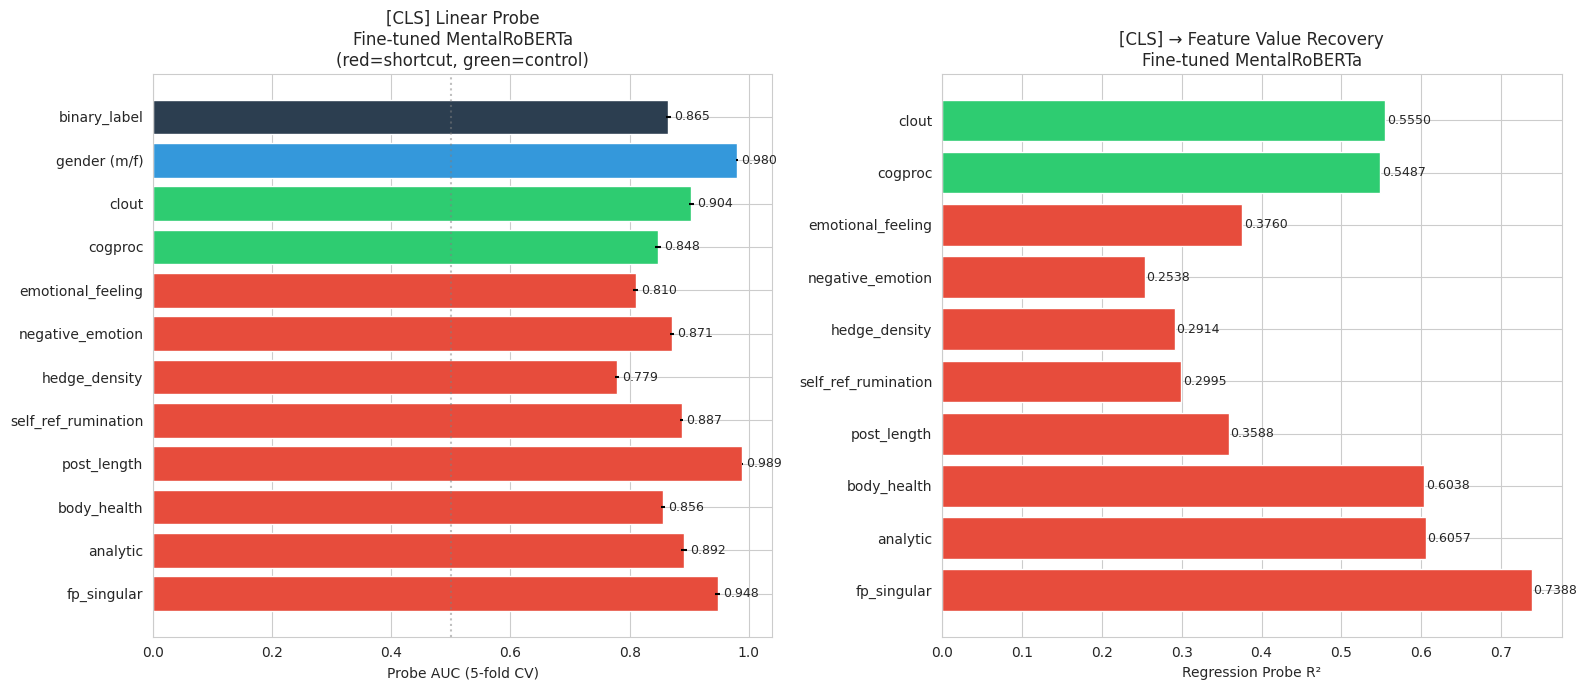

Saved → data/stage2_mentalroberta/finetuned/probing_results.png


In [18]:
plot_probing(probe_df_ft, aucs_g_ft, aucs_l_ft,
             PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
             title_suffix='Fine-tuned MentalRoBERTa',
             save_path=f'{OUT_FT}/probing_results.png')
probe_df_ft.to_csv(f'{OUT_FT}/probing_results.csv', index=False)

## B2 — Layer-wise Probing (Fine-tuned)

In [19]:
print(f"Extracting all-layer [CLS] (fine-tuned) for {len(df):,} posts …")
all_layer_cls_ft = extract_cls_all_layers(df['text'].tolist(), encoder_ft, tokenizer_ft_loaded)
print(f"Got {len(all_layer_cls_ft)} layers")

Extracting all-layer [CLS] (fine-tuned) for 32,200 posts …
  Batch 501/504
Got 13 layers


In [20]:
print("Running layer-wise probing (fine-tuned) …")
layer_probe_df_ft, layer_names_ft = run_layerwise_probing(
    all_layer_cls_ft, targets, PROBE_FEATURES,
    SHORTCUT_FEATURES, CONTROL_FEATURES, mf_idx_arr
)
pivot_ft = layer_probe_df_ft.pivot(index='target', columns='layer_name', values='AUC')
pivot_ft = pivot_ft[layer_names_ft]
print(pivot_ft.round(3).to_string())

Running layer-wise probing (fine-tuned) …
  Layer Emb  done
  Layer L1   done
  Layer L2   done
  Layer L3   done
  Layer L4   done
  Layer L5   done
  Layer L6   done
  Layer L7   done
  Layer L8   done
  Layer L9   done
  Layer L10  done
  Layer L11  done
  Layer L12  done
layer_name           Emb     L1     L2     L3     L4     L5     L6     L7     L8     L9    L10    L11    L12
target                                                                                                      
analytic             0.5  0.969  0.965  0.960  0.955  0.946  0.939  0.928  0.920  0.915  0.906  0.896  0.885
binary_label         0.5  0.779  0.788  0.799  0.809  0.819  0.829  0.846  0.853  0.854  0.856  0.858  0.863
body_health          0.5  0.882  0.879  0.880  0.878  0.874  0.867  0.862  0.857  0.847  0.852  0.858  0.851
clout                0.5  0.942  0.942  0.935  0.930  0.927  0.921  0.911  0.900  0.898  0.897  0.897  0.901
cogproc              0.5  0.915  0.915  0.907  0.905  0.894  0.890  0.

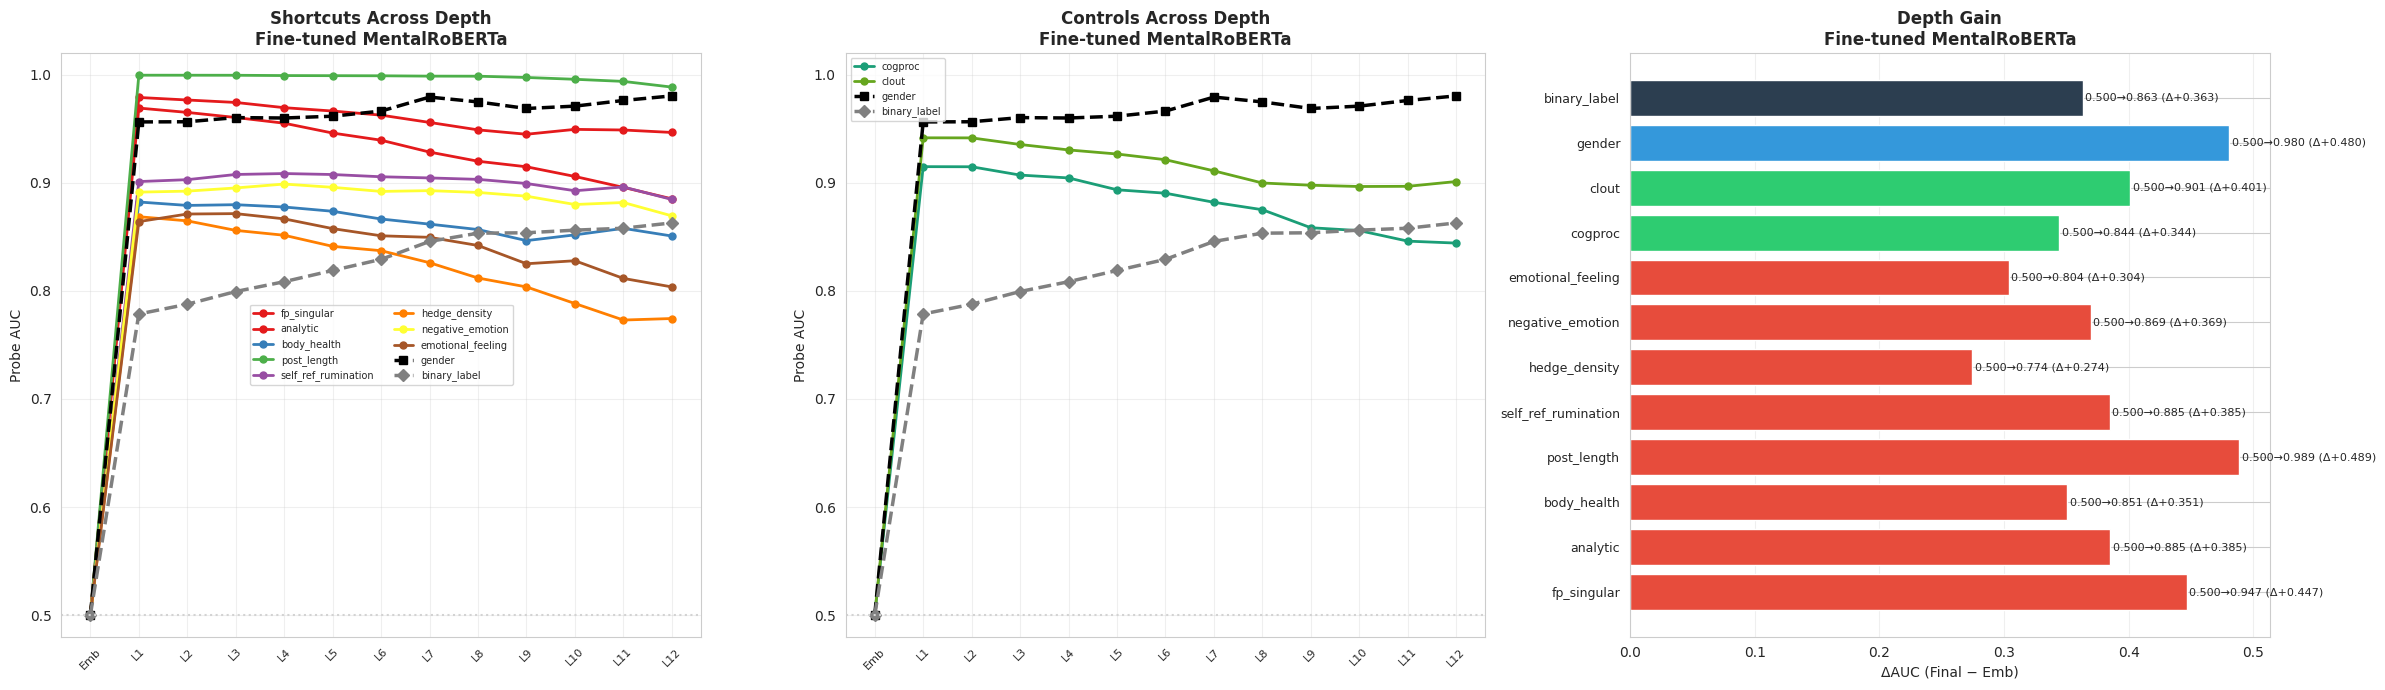

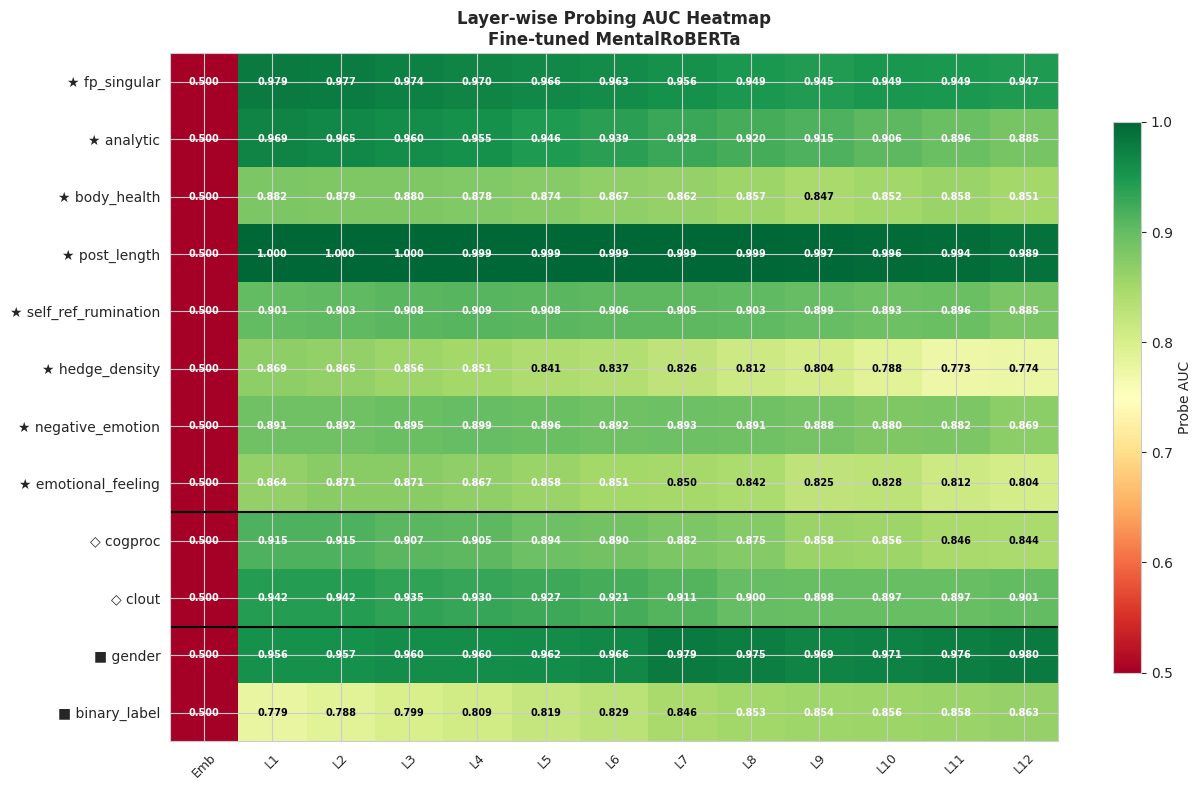

Saved → data/stage2_mentalroberta/finetuned/layerwise_layerwise.png + _heatmap.png


In [21]:
plot_layerwise(layer_probe_df_ft, layer_names_ft,
               SHORTCUT_FEATURES, CONTROL_FEATURES, all_targets_ordered,
               title_suffix='Fine-tuned MentalRoBERTa',
               save_prefix=f'{OUT_FT}/layerwise')
layer_probe_df_ft.to_csv(f'{OUT_FT}/layerwise_probing.csv', index=False)

## B3 — SHAP Attribution (Fine-tuned)

SHAP is computed on the raw LIWC feature logistic model (same as Part A and notebooks 02/02b).
Included for completeness and self-contained reproducibility.

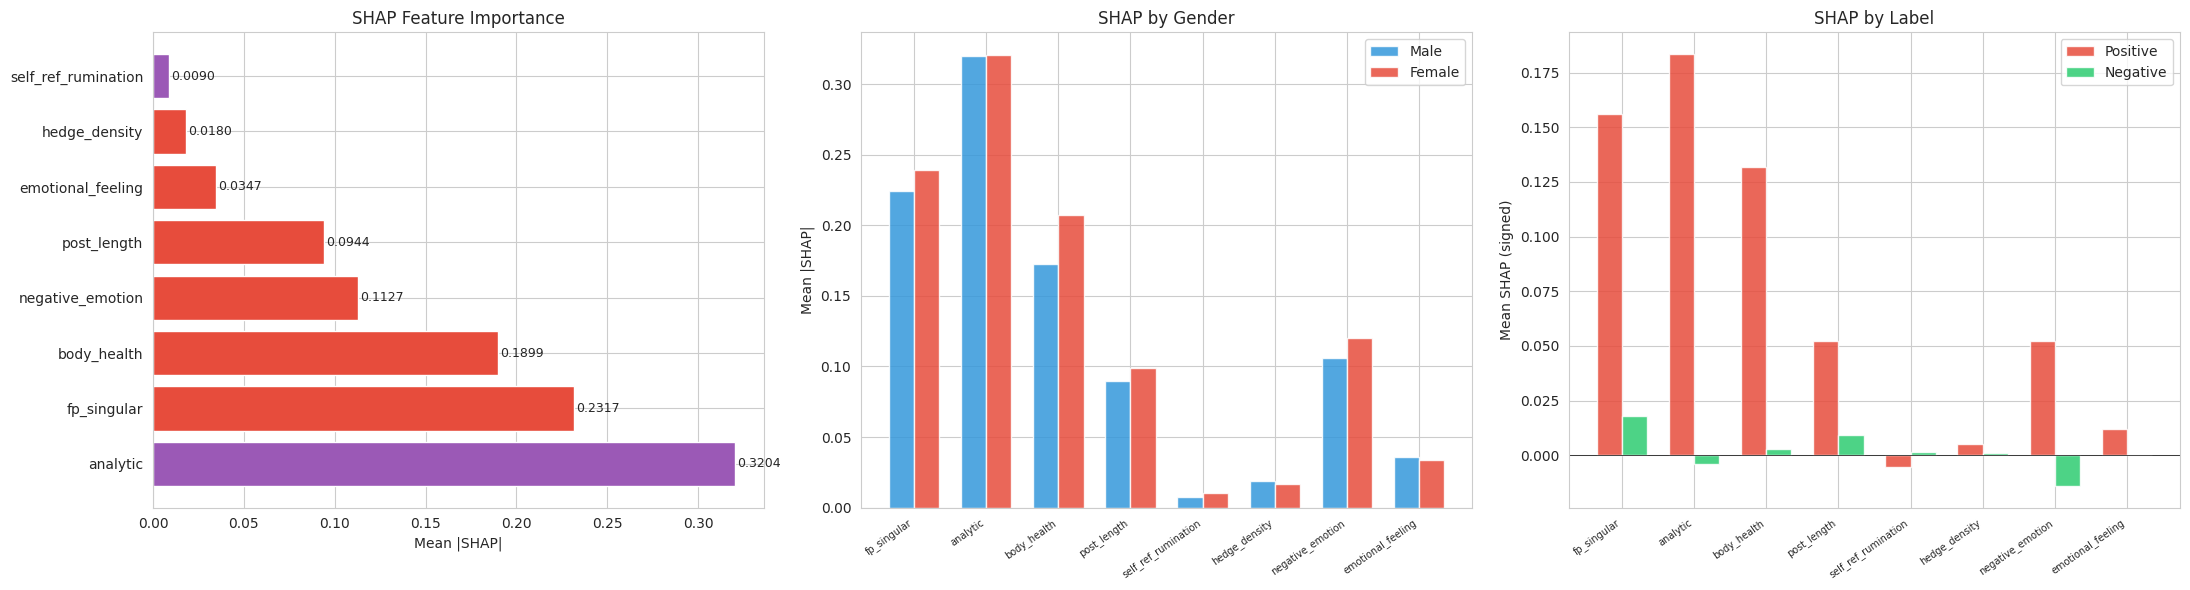

Saved → data/stage2_mentalroberta/finetuned/shap_analysis.png


In [22]:
# SHAP values are identical to Part A (same feature model) — reuse and save to finetuned dir
np.save(f'{OUT_FT}/shap_values.npy', shap_values)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
axes[0].barh(range(len(order)), mean_abs[order], color=bar_c, edgecolor='white')
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([SHORTCUT_FEATURES[i] for i in order], fontsize=10)
axes[0].set_xlabel('Mean |SHAP|'); axes[0].set_title('SHAP Feature Importance')
for i, idx in enumerate(order):
    axes[0].text(mean_abs[idx]+0.001, i, f'{mean_abs[idx]:.4f}', va='center', fontsize=9)

axes[1].bar(x-w/2, shap_df[shap_df['gender']=='male'][SHORTCUT_FEATURES].abs().mean().values,
            w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x+w/2, shap_df[shap_df['gender']=='female'][SHORTCUT_FEATURES].abs().mean().values,
            w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[1].set_ylabel('Mean |SHAP|'); axes[1].set_title('SHAP by Gender'); axes[1].legend()

axes[2].bar(x-w/2, pos_s.values, w, label='Positive', color='#e74c3c', alpha=0.85)
axes[2].bar(x+w/2, neg_s.values, w, label='Negative', color='#2ecc71', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[2].set_ylabel('Mean SHAP (signed)'); axes[2].set_title('SHAP by Label')
axes[2].axhline(0, color='black', linewidth=0.5); axes[2].legend()
plt.tight_layout()
plt.savefig(f'{OUT_FT}/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); print(f"Saved → {OUT_FT}/shap_analysis.png")

## B4 — Feature Ablation (Fine-tuned)

In [23]:
ablation_df_ft, strat_df_ft, baseline_auc_ft, aucs_all_ft, drop_all_ft = \
    run_ablation(df, ALL_18_FEATURES, SHORTCUT_FEATURES, GENDER_COL)
ablation_df_ft

Baseline (18 features): AUC = 0.7214 ± 0.0074
  Ablate fp_singular              : AUC=0.7166  (Δ=+0.0049)
  Ablate analytic                 : AUC=0.7186  (Δ=+0.0028)
  Ablate body_health              : AUC=0.7032  (Δ=+0.0182)
  Ablate post_length              : AUC=0.7173  (Δ=+0.0041)
  Ablate self_ref_rumination      : AUC=0.7215  (Δ=-0.0000)
  Ablate hedge_density            : AUC=0.7215  (Δ=-0.0001)
  Ablate negative_emotion         : AUC=0.7208  (Δ=+0.0006)
  Ablate emotional_feeling        : AUC=0.7214  (Δ=-0.0000)
  Ablate ALL: AUC=0.6503  (Δ=+0.0711)


,ablated,AUC_after,AUC_std,AUC_drop,drop_pct
0,fp_singular,0.716560,0.008243,0.004857,0.673260
1,analytic,0.718633,0.007361,0.002784,0.385926
2,body_health,0.703240,0.005938,0.018176,2.519555
3,post_length,0.717294,0.007624,0.004123,0.571505
4,self_ref_rumination,0.721459,0.007360,-0.000042,-0.005855
5,hedge_density,0.721535,0.007457,-0.000119,-0.016458
6,negative_emotion,0.720826,0.007283,0.000590,0.081829
7,emotional_feeling,0.721434,0.007421,-0.000017,-0.002387


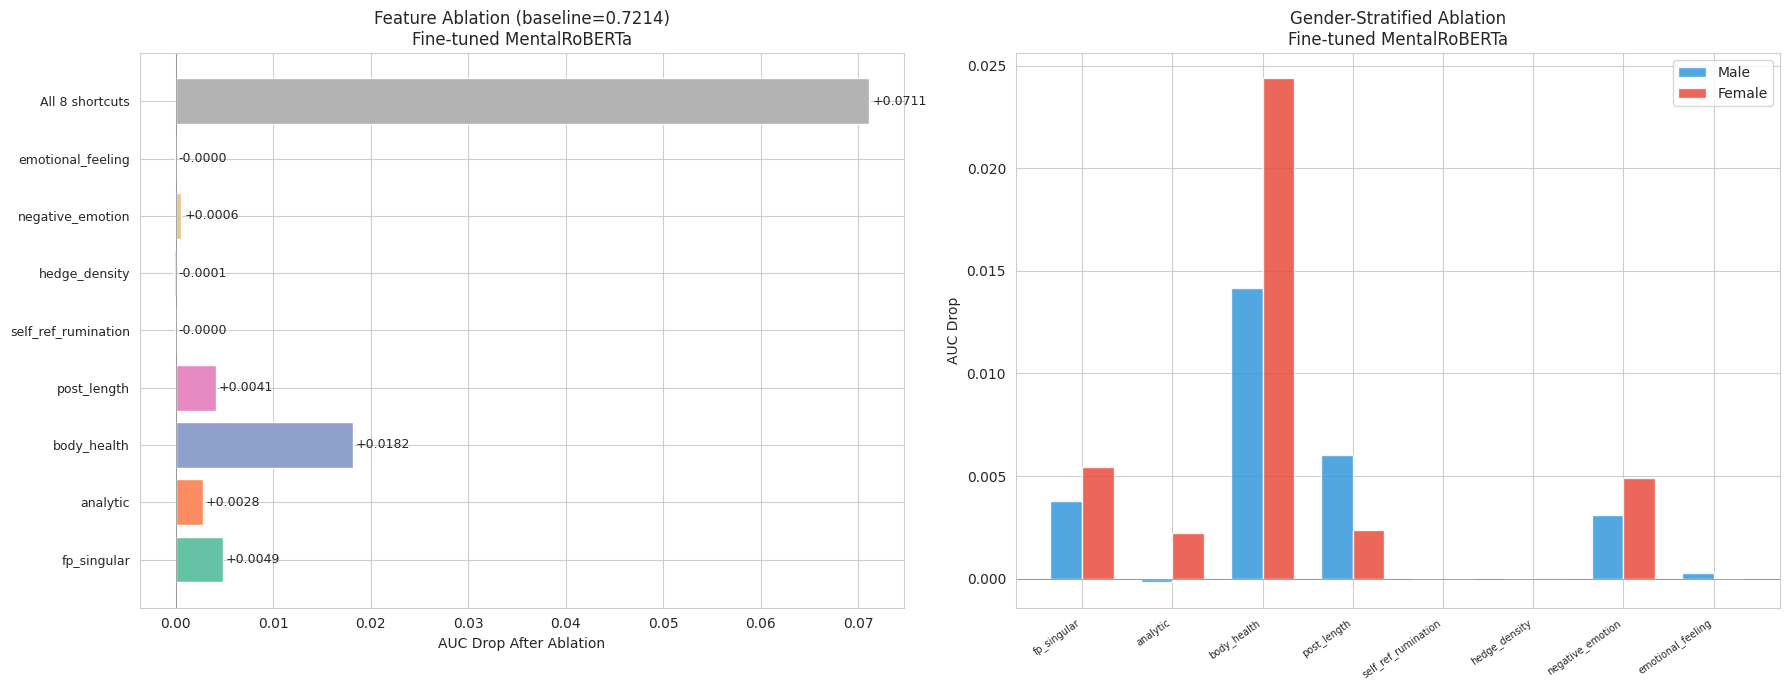

Saved → data/stage2_mentalroberta/finetuned/ablation_analysis.png


In [24]:
plot_ablation(ablation_df_ft, strat_df_ft, baseline_auc_ft, drop_all_ft,
              SHORTCUT_FEATURES, 'Fine-tuned MentalRoBERTa',
              save_path=f'{OUT_FT}/ablation_analysis.png')
ablation_df_ft.to_csv(f'{OUT_FT}/ablation_results.csv', index=False)
strat_df_ft.to_csv(f'{OUT_FT}/gender_stratified_ablation.csv', index=False)

---
# Summary: Frozen vs Fine-tuned MentalRoBERTa

Side-by-side comparison of probing AUC and R² across both conditions.

NameError: name 'probe_df_frozen' is not defined

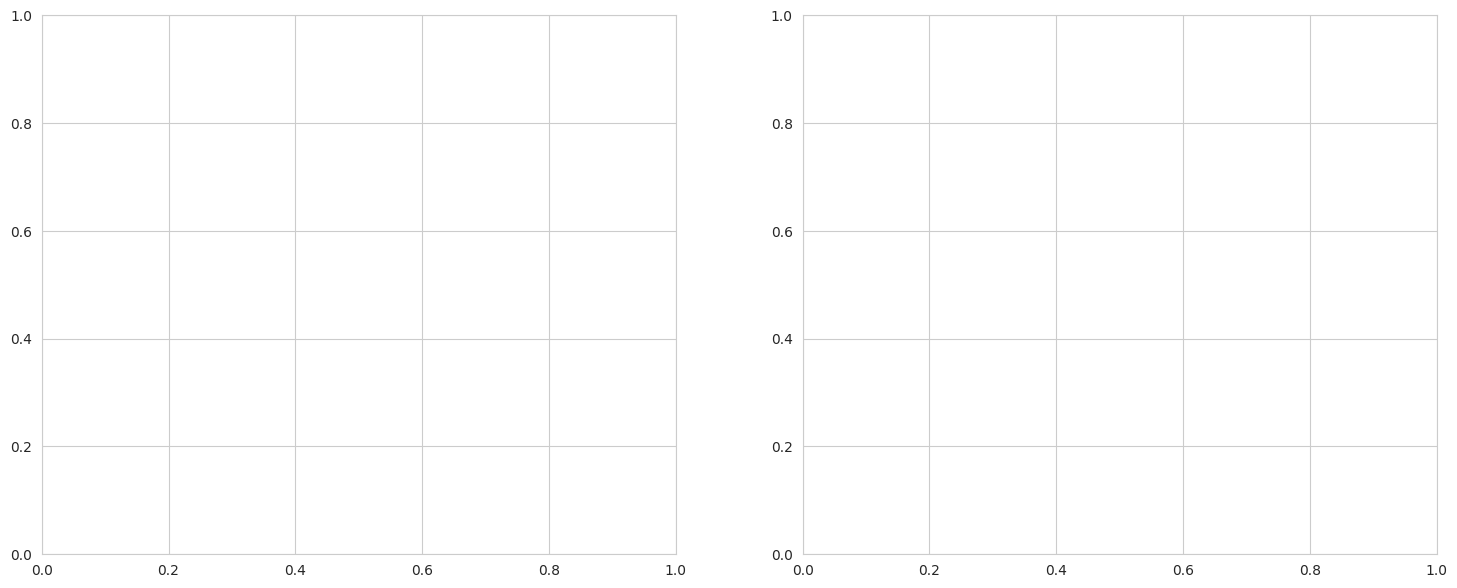

In [25]:
# ── Side-by-side probing AUC comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

all_labels = PROBE_FEATURES + ['gender (m/f)', 'binary_label']

def get_aucs(probe_df, aucs_g, aucs_l):
    return [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
            for f in PROBE_FEATURES] + [aucs_g.mean(), aucs_l.mean()]

aucs_frz = get_aucs(probe_df_frozen, aucs_g_frozen, aucs_l_frozen)
aucs_ftn = get_aucs(probe_df_ft, aucs_g_ft, aucs_l_ft)

x = np.arange(len(all_labels)); w = 0.35
axes[0].barh(x-w/2, aucs_frz, w, label='Frozen',     color='#3498db', alpha=0.85)
axes[0].barh(x+w/2, aucs_ftn, w, label='Fine-tuned', color='#e74c3c', alpha=0.85)
axes[0].set_yticks(x); axes[0].set_yticklabels(all_labels, fontsize=10)
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Probe AUC (5-fold CV)')
axes[0].set_title('Probe AUC: Frozen vs Fine-tuned\nMentalRoBERTa', fontweight='bold')
axes[0].legend()

r2_frz = probe_df_frozen['probe_R2'].values
r2_ftn = probe_df_ft['probe_R2'].values
x2 = np.arange(len(PROBE_FEATURES))
axes[1].barh(x2-w/2, r2_frz, w, label='Frozen',     color='#3498db', alpha=0.85)
axes[1].barh(x2+w/2, r2_ftn, w, label='Fine-tuned', color='#e74c3c', alpha=0.85)
axes[1].set_yticks(x2); axes[1].set_yticklabels(PROBE_FEATURES, fontsize=10)
axes[1].set_xlabel('Regression Probe R²')
axes[1].set_title('Probe R²: Frozen vs Fine-tuned\nMentalRoBERTa', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUT_ROOT}/comparison_frozen_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_ROOT}/comparison_frozen_vs_finetuned.png")

In [ ]:
print("=" * 65)
print("FINAL SUMMARY — MentalRoBERTa (Frozen vs Fine-tuned)")
print("=" * 65)

header = f"{'Feature':25s}  {'Frz AUC':>8}  {'FT AUC':>7}  {'ΔAUC':>6}  {'Frz R²':>7}  {'FT R²':>6}  {'ΔR²':>6}"
print(f"\n{header}")
print("-" * len(header))

for feat in PROBE_FEATURES:
    frz_row = probe_df_frozen[probe_df_frozen['feature']==feat].iloc[0]
    ft_row  = probe_df_ft[probe_df_ft['feature']==feat].iloc[0]
    da = ft_row['probe_AUC_median_split'] - frz_row['probe_AUC_median_split']
    dr = ft_row['probe_R2'] - frz_row['probe_R2']
    tag = '★' if frz_row['role']=='shortcut' else '◇'
    print(f"{tag} {feat:24s}  {frz_row['probe_AUC_median_split']:8.3f}  "
          f"{ft_row['probe_AUC_median_split']:7.3f}  {da:+6.3f}  "
          f"{frz_row['probe_R2']:7.4f}  {ft_row['probe_R2']:6.4f}  {dr:+6.4f}")

print(f"\n  Gender AUC : frozen={aucs_g_frozen.mean():.3f}  finetuned={aucs_g_ft.mean():.3f}  "
      f"Δ={aucs_g_ft.mean()-aucs_g_frozen.mean():+.3f}")
print(f"  Label  AUC : frozen={aucs_l_frozen.mean():.3f}  finetuned={aucs_l_ft.mean():.3f}  "
      f"Δ={aucs_l_ft.mean()-aucs_l_frozen.mean():+.3f}")

print(f"\nFiles saved to: {OUT_ROOT}/")
for sub in ['frozen', 'finetuned']:
    for fname in ['probing_results.csv', 'layerwise_probing.csv', 'ablation_results.csv',
                  'gender_stratified_ablation.csv', 'shap_values.npy']:
        print(f"  {OUT_ROOT}/{sub}/{fname}")